In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = "/media/amit/Storage/PROJECTS/Work_in_progress/MotoGP/MotoGP-Team-Detection/data/teams"
valid_extensions = ('.jpg', '.jpeg', '.png')
stats = []

In [3]:
for team_name in sorted(os.listdir(DATA_DIR)):
    team_dir = os.path.join(DATA_DIR, team_name)
    if os.path.isdir(team_dir):
        image_count = len([f for f in os.listdir(team_dir) if f.lower().endswith(valid_extensions)])
        stats.append({'team': team_name, 'image_count': image_count})

In [4]:
# Separate 'unsorted' if it exists (so it doesn't skew the chart)
df = pd.DataFrame(stats)
unsorted_df = df[df['team'] == 'unsorted']
teams_df = df[df['team'] != 'unsorted'].sort_values(by='image_count', ascending=False)

In [5]:
# Display the Data Table
print("--- Team Distribution ---")
print(teams_df.to_string(index=False))
print(f"\nUnsorted Images Remaining: {unsorted_df['image_count'].sum() if not unsorted_df.empty else 0}")
print(f"Total Sorted Images: {teams_df['image_count'].sum()}")

--- Team Distribution ---
              team  image_count
   aprilia_factory           70
     ducati_lenovo           70
         honda_hrc           68
    yamaha_monster           65
         ktm_tech3           61
     yamaha_pramac           60
    ducati_gresini           60
         honda_lcr           60
       ducati_vr46           58
       ktm_factory           56
aprilia_trackhouse           40

Unsorted Images Remaining: 0
Total Sorted Images: 668


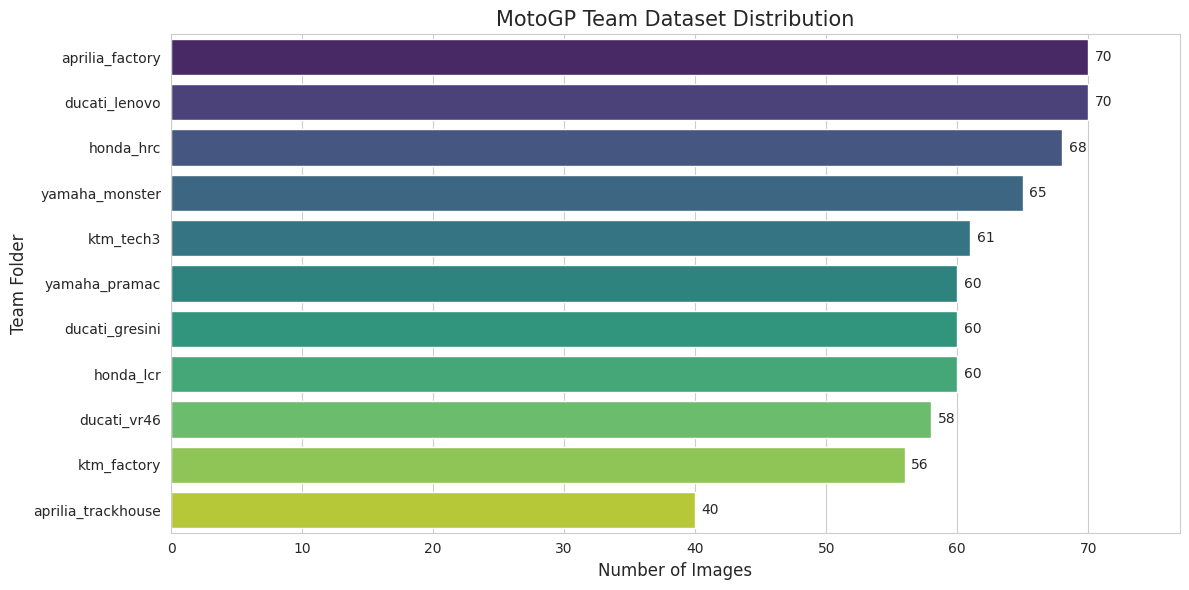

In [6]:
# 5. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(data=teams_df, x='image_count', y='team', palette='viridis', hue='team', legend=False)

# Add count labels to the end of each bar
for i, p in enumerate(barplot.patches):
    width = p.get_width()
    plt.text(width + 0.5,       # x-position
             p.get_y() + p.get_height() / 2, # y-position
             f'{int(width)}',   # text
             va='center')       # vertical alignment

plt.title('MotoGP Team Dataset Distribution', fontsize=15)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Team Folder', fontsize=12)
plt.xlim(0, teams_df['image_count'].max() * 1.1) # Add some breathing room on the right
plt.tight_layout()